## Binning

In [1]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [30]:
df = pd.read_csv('./data/train.csv',usecols=['Age','Fare','Survived'])

In [31]:
df.shape

(891, 3)

In [32]:
df = df.dropna()

In [33]:
df.shape

(714, 3)

In [34]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [36]:
clf = DecisionTreeClassifier()

In [37]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [38]:
accuracy_score(y_test,y_pred)

0.6643356643356644

In [39]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6289123630672926)

In [40]:
kbin_age = KBinsDiscretizer(
  n_bins=15,
  encode='ordinal',
  strategy='quantile',
  quantile_method="averaged_inverted_cdf"
)
kbin_fare = KBinsDiscretizer(
  n_bins=15,
  encode='ordinal',
  strategy='quantile',
  quantile_method="averaged_inverted_cdf"
)

In [41]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [42]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [43]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  5.  , 16.  , 18.  , 21.  , 22.  , 25.  , 27.  , 29.  ,
              31.  , 34.  , 36.  , 41.  , 47.  , 52.  , 80.  ])             ],
      dtype=object)

In [45]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.2292,   7.7958,   7.925 ,   8.05  ,  10.4625,
               12.875 ,  14.1083,  18.75  ,  26.    ,  26.55  ,  31.    ,
               46.9   ,  69.3   ,  91.0792, 512.3292])                   ],
      dtype=object)

In [46]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [47]:
output.sample(5)

,age,age_trf,fare,fare_trf
750,4.0,0.0,23.0000,8.0
549,8.0,1.0,36.7500,11.0
38,18.0,3.0,18.0000,7.0
261,3.0,0.0,31.3875,11.0
541,9.0,1.0,31.2750,11.0


In [49]:
output['age_labels'] = pd.cut(x=X_train['Age'],
  bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)
output['fare_labels'] = pd.cut(x=X_train['Fare'],
  bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)

In [50]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
690,31.0,9.0,57.000,12.0,"(29.0, 31.0]","(46.9, 69.3]"
554,22.0,5.0,7.775,1.0,"(21.0, 22.0]","(7.229, 7.796]"
632,32.0,9.0,30.500,10.0,"(31.0, 34.0]","(26.55, 31.0]"
504,16.0,2.0,86.500,13.0,"(5.0, 16.0]","(69.3, 91.079]"
594,37.0,11.0,26.000,9.0,"(36.0, 41.0]","(18.75, 26.0]"


In [51]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [52]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [53]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6373043818466353)

In [57]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy,
        quantile_method="averaged_inverted_cdf"
    )
    
    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy,
        quantile_method="averaged_inverted_cdf"
    )
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6345070422535211


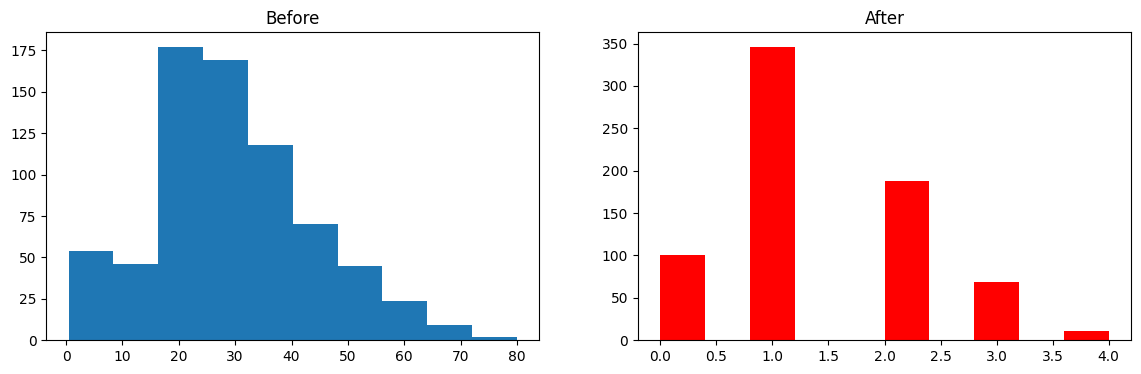

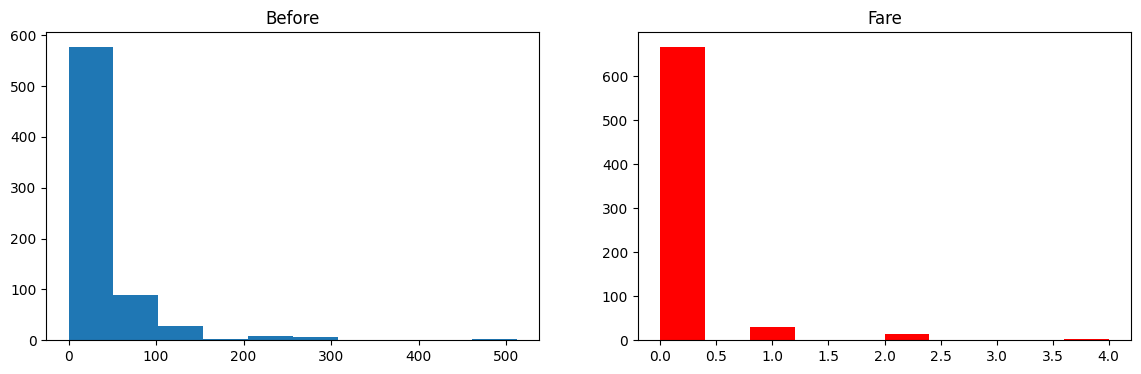

In [64]:
discretize(5,'uniform')

0.6359154929577465


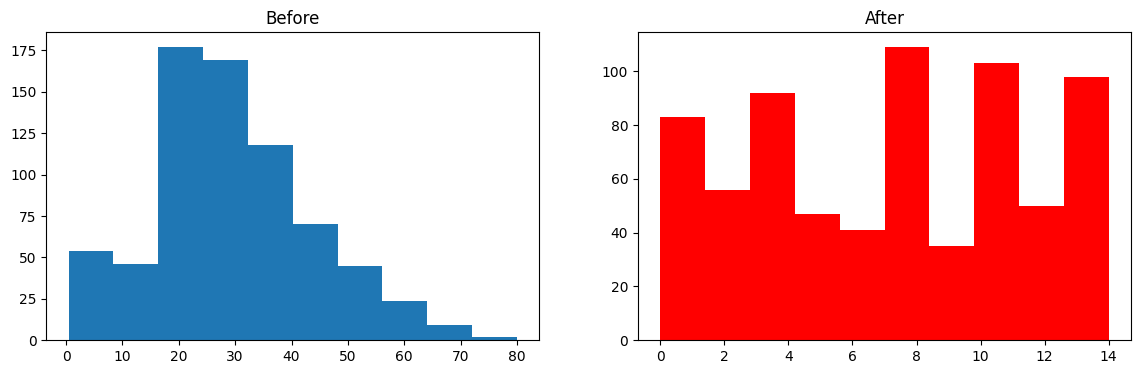

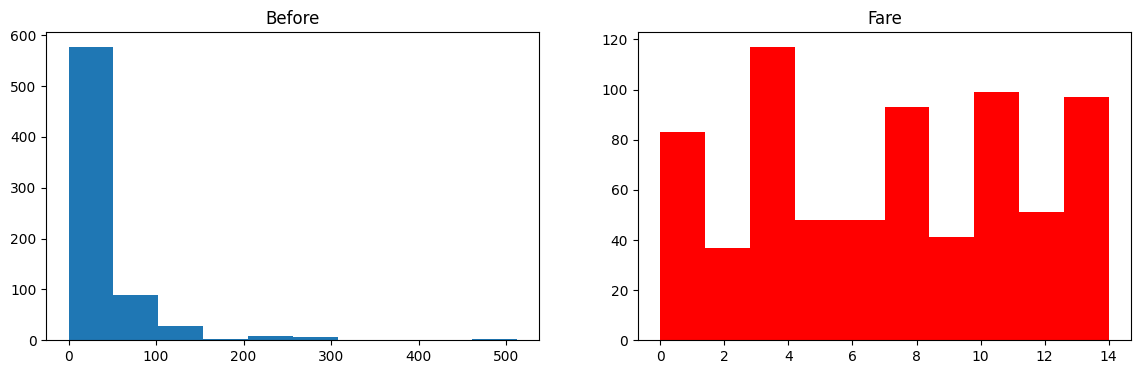

In [71]:
discretize(15,'quantile')

0.6303208137715179


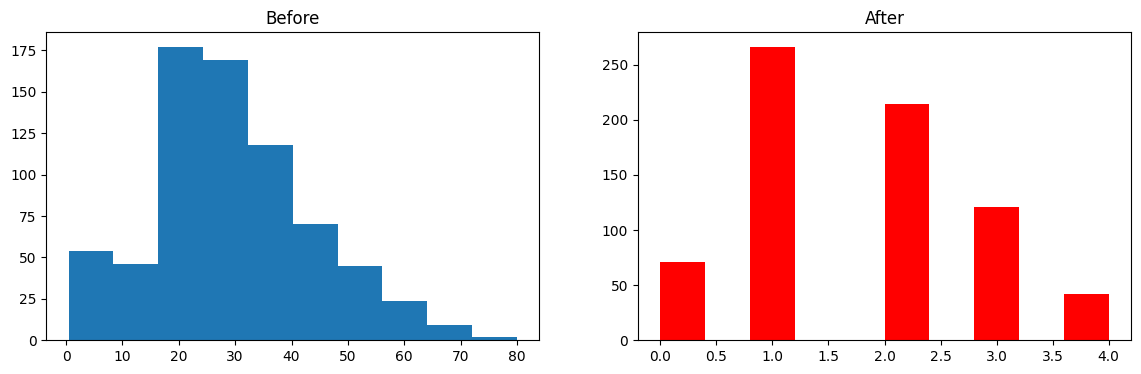

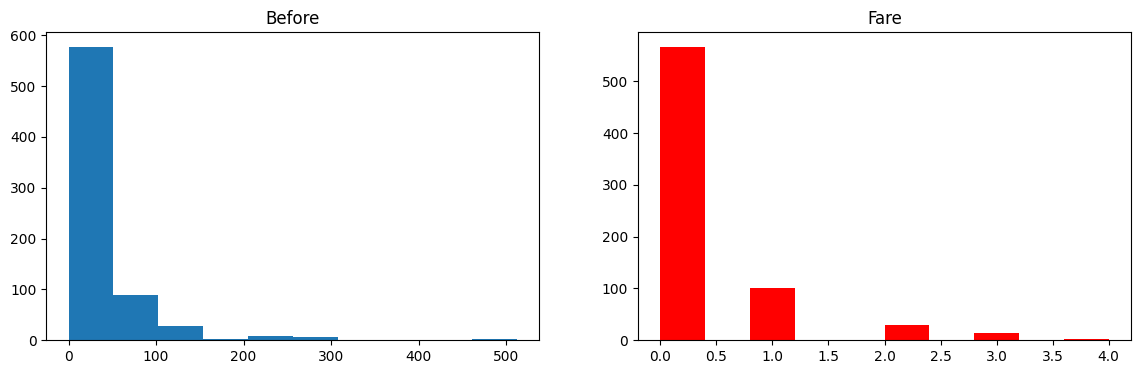

In [74]:
discretize(5,'kmeans')